In [1]:
import torch
import matplotlib.pyplot as plt

# 1D Heat Equation with PyTorch

We solve the one-dimensional heat equation

$$
u_t = \alpha u_{xx}
$$

on the spatial domain

$$
0 < x < L
$$

with zero boundary conditions

$$
u(0,t) = 0, \qquad u(L,t) = 0
$$

and initial condition

$$
u(x,0) = \sin\left(\frac{\pi x}{L}\right).
$$

## configutation on grid and time 

In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"

alpha = 1.0
L     = 1.0
T     = 0.1
Nx    = 51
dx    = L / (Nx - 1)

x = torch.linspace(0, L, Nx, device=device)

# Stability condition for explicit FDM:
r  = 0.4  # r = alpha * dt / dx^2 <= 1/2
dt = r * dx**2 / alpha
Nt = int(T / dt)

dt = T / Nt
r  = alpha * dt / dx**2

print("device:", device)
print("dx =", dx)
print("dt =", dt)
print("r =", r)


# set x_grid
x_cpu = x.detach().cpu().numpy()


device: cuda
dx = 0.02
dt = 0.00016
r = 0.4


The exact solution depends on time $t$:

$$
u(x,t)
=
e^{-\alpha (\pi/L)^2 t}
\sin\left(\frac{\pi x}{L}\right).
$$


In [28]:
def exact_1d(x, t):
    return torch.exp(
        torch.tensor(-alpha * (torch.pi / L)**2 * t, device=device)
    ) * torch.sin(torch.pi * x / L)

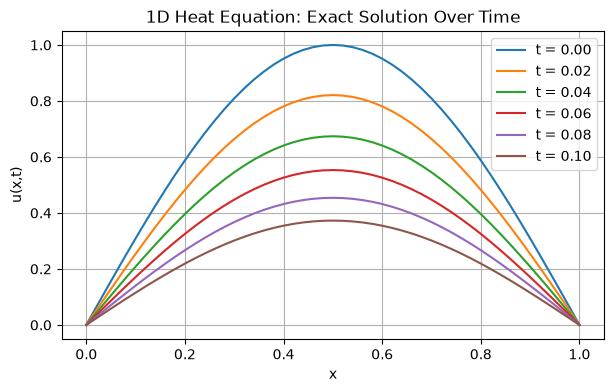

In [29]:



# choose several time points
t_history = torch.linspace(0, T, 6)  # 6 snapshots from 0 to T


plt.figure(figsize=(7, 4))

for t in t_history :
    u_exact     = exact_1d(x, t.item())
    u_exact_cpu = u_exact.detach().cpu().numpy()

    plt.plot(x_cpu, u_exact_cpu, label=f"t = {t.item():.2f}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("1D Heat Equation: Exact Solution Over Time")
plt.legend()
plt.grid(True)
plt.show()




# ## Heat map figure 
# t_grid = torch.linspace(0, T, 100)
# u_all = []

# for t in t_grid:
#     u_exact = exact_1d(x, t.item())
#     u_all.append(u_exact.detach().cpu())

# u_all = torch.stack(u_all)  # shape: [time, x]

# plt.figure(figsize=(7, 4))
# plt.imshow(
#     u_all.numpy(),
#     extent=[x_cpu.min(), x_cpu.max(), 0, T],
#     aspect="auto",
#     origin="lower"
# )

# plt.colorbar(label="u(x,t)")
# plt.xlabel("x")
# plt.ylabel("t")
# plt.title("1D Heat Equation: Exact Solution Over Time")
# plt.show()

# FDM Update Rule for the 1D Heat Equation

The 1D heat equation is

$$
u_t = \alpha u_{xx}.
$$

Using finite differences,

$$
u_t \approx \frac{u_i^{n+1} - u_i^n}{\Delta t}
$$

and

$$
u_{xx} \approx \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}.
$$

Substituting into the heat equation gives

$$
\frac{u_i^{n+1} - u_i^n}{\Delta t}
=
\alpha
\frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}.
$$

Therefore, the explicit FDM update rule is

$$
u_i^{n+1}
=
u_i^n
+
r
\left(
u_{i+1}^n - 2u_i^n + u_{i-1}^n
\right),
$$

where

$$
r = \frac{\alpha \Delta t}{\Delta x^2}.
$$

Equivalently,

$$
u_i^{n+1}
=
r u_{i-1}^n
+
(1 - 2r)u_i^n
+
r u_{i+1}^n.
$$

For stability,

The coefficient $(1 - 2r)$ should be nonnegative so that the update is a weighted average of neighboring values. If this coefficient becomes negative, the method can create artificial oscillations and the numerical solution may become unstable.

Therefore,

$$
1 - 2r \geq 0
$$

which gives

$$
r \leq \frac{1}{2}.
$$


In [33]:

# initial condition
u = torch.sin(torch.pi * x / L)

# boundary conditions: u(0,t)=u(L,t)=0
u[0] = 0.0
u[-1] = 0.0


# store solution history
u_history = []
t_history = []

save_every = 100

for n in range(Nt + 1):

    # current time
    t_now = n * dt

    # save solution and time
    if n % save_every == 0:
        u_history.append(u.detach().cpu().clone())
        t_history.append(t_now)
        

    # copy current solution
    u_old = u.clone()

    # explicit FDM update
    u[1:-1] = ( r * u_old[:-2] + (1 - 2 * r) * u_old[1:-1] + r * u_old[2:] )

    # boundary conditions
    u[0] = 0.0
    u[-1] = 0.0

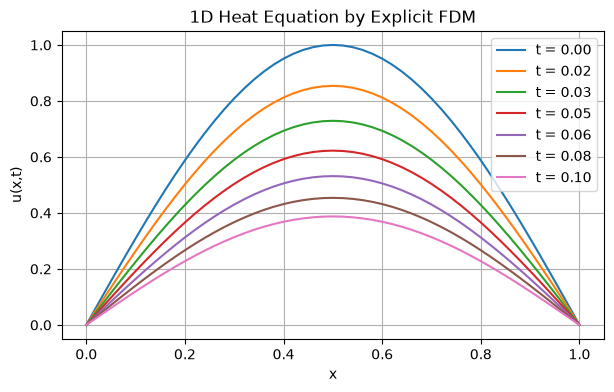

In [34]:
x_cpu = x.detach().cpu().numpy()

plt.figure(figsize=(7, 4))

for k, u_snapshot in enumerate(u_history):
    t = k * 100 * dt
    plt.plot(x_cpu, u_snapshot.numpy(), label=f"t = {t:.2f}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("1D Heat Equation by Explicit FDM")
plt.legend()
plt.grid(True)
plt.show()

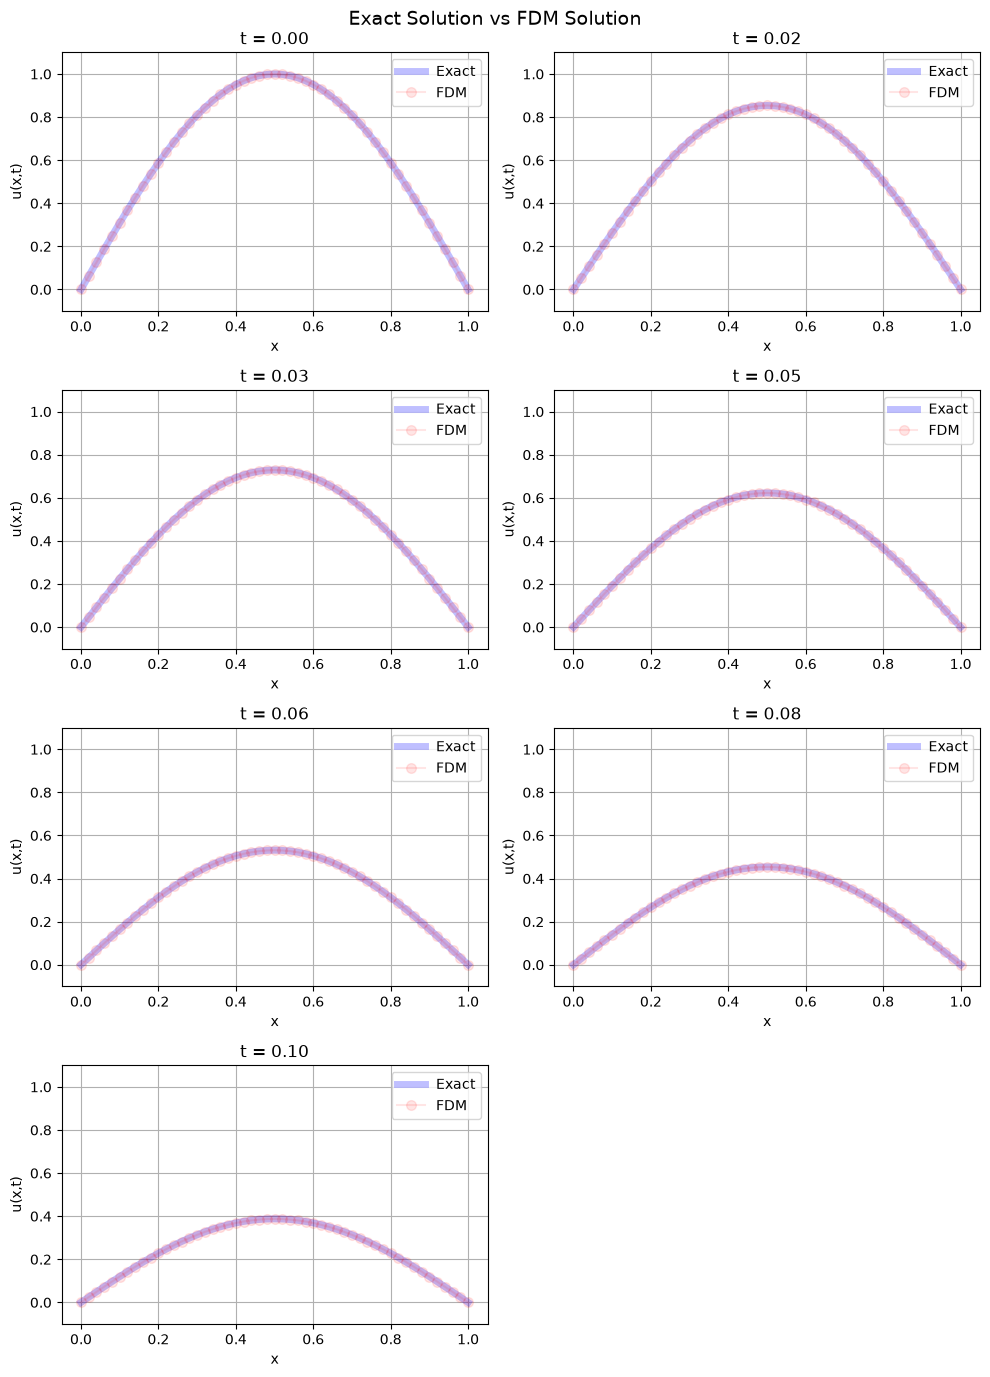

In [56]:
# -----------------------
# Compare exact and FDM using subplots
# -----------------------

import math
import matplotlib.pyplot as plt

x_cpu = x.detach().cpu().numpy()

num_plots = len(t_history)

# choose subplot layout
ncols = 2
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.5 * nrows))

# make axes always iterable
axes = axes.flatten()

for k, (t_now, u_snapshot) in enumerate(zip(t_history, u_history)):

    ax = axes[k]

    # exact solution at same time
    u_exact = exact_1d(x, t_now)
    u_exact_cpu = u_exact.detach().cpu().numpy()

    # FDM solution
    u_fdm_cpu = u_snapshot.numpy()

    ax.plot(
        x_cpu,
        u_exact_cpu,
        "-",
        color='blue',
        label="Exact",
        linewidth=5,
        alpha=0.25,
    )

    ax.plot(
        x_cpu,
        u_fdm_cpu,
        "-o",
        color='red',        
        label="FDM",
        alpha=0.1,
        markersize=7,
    )

    ax.set_title(f"t = {t_now:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("u(x,t)")
    ax.grid(True)
    ax.legend()
    
    ax.set_ylim(-0.1, 1.1)  # set y-limits for better comparison

# remove unused subplots
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Exact Solution vs FDM Solution", fontsize=14)
plt.tight_layout()
plt.show()

In [1]:
# ============================================================
# 2D Heat Equation with PyTorch
# u_t = alpha (u_xx + u_yy)
# u = 0 on boundary
# u(x,y,0) = sin(pi x / Lx) sin(pi y / Ly)
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

alpha = 1.0
Lx = 1.0
Ly = 1.0
T = 0.05

Nx = 51
Ny = 51

dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

x = torch.linspace(0, Lx, Nx, device=device)
y = torch.linspace(0, Ly, Ny, device=device)

X, Y = torch.meshgrid(x, y, indexing="ij")

# Stability condition for explicit 2D FDM:
# alpha * dt * (1/dx^2 + 1/dy^2) <= 1/2
dt_stable = 0.5 / (alpha * (1 / dx**2 + 1 / dy**2))
dt = 0.8 * dt_stable

Nt = int(T / dt)
dt = T / Nt

rx = alpha * dt / dx**2
ry = alpha * dt / dy**2

print("device:", device)
print("dx =", dx)
print("dy =", dy)
print("dt =", dt)
print("rx =", rx)
print("ry =", ry)
print("rx + ry =", rx + ry)

def exact_2d(X, Y, t):
    decay = torch.exp(
        torch.tensor(
            -alpha * ((torch.pi / Lx)**2 + (torch.pi / Ly)**2) * t,
            device=device
        )
    )
    return decay * torch.sin(torch.pi * X / Lx) * torch.sin(torch.pi * Y / Ly)

# Initial condition
u = torch.sin(torch.pi * X / Lx) * torch.sin(torch.pi * Y / Ly)

# FDM time stepping
for n in range(Nt):
    u_new = u.clone()

    u_new[1:-1, 1:-1] = (
        u[1:-1, 1:-1]
        + rx * (
            u[2:, 1:-1]
            - 2 * u[1:-1, 1:-1]
            + u[:-2, 1:-1]
        )
        + ry * (
            u[1:-1, 2:]
            - 2 * u[1:-1, 1:-1]
            + u[1:-1, :-2]
        )
    )

    # Boundary conditions
    u_new[0, :] = 0.0
    u_new[-1, :] = 0.0
    u_new[:, 0] = 0.0
    u_new[:, -1] = 0.0

    u = u_new

u_exact = exact_2d(X, Y, T)
error = torch.abs(u - u_exact)

print("Max error:", error.max().item())

NameError: name 'torch' is not defined

In [58]:
# # Plot 2D result

# X_cpu = X.cpu()
# Y_cpu = Y.cpu()
# u_cpu = u.cpu()
# u_exact_cpu = u_exact.cpu()
# error_cpu = error.cpu()

# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# data_list = [
#     (u_exact_cpu, "Exact solution"),
#     (u_cpu, "FDM solution"),
#     (error_cpu, "Absolute error"),
# ]

# for ax, (data, title) in zip(axes, data_list):
#     im = ax.contourf(X_cpu, Y_cpu, data, levels=30, cmap="viridis")
#     ax.set_title(title)
#     ax.set_xlabel("x")
#     ax.set_ylabel("y")
#     fig.colorbar(im, ax=ax)

# plt.tight_layout()
# plt.show()